# Notebook 15 — Stage 1 Detector v2 (standalone: precompute + focal + eval)

NB14'in iyilestirilmis surumu, **kendi precompute'u var** (Drive H5 yedegine bagimli degil).

Iyilestirmeler (NB14 CPM 0.228 -> hedef yukari):
- **Focal loss (CenterNet)** — keskin tepe, FP bastirma
- **NEG_PER_POS 1.5 -> 10** (config knob; FP'nin ana kaldiraci), ~%60 hard negatif (damar/lenf) + %40 random akciger
- **52 epoch**
- Cikti: `stage1_detector_v2.pth`, H5: `_v2` (NB14'unkini bozmaz)

HU [-1000,1000]. Nodul merkezi = radyolog konsensus bbox. NPZ'ler local'de varsa tekrar kopyalanmaz.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, json, gc, time, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter, maximum_filter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import h5py
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

Mounted at /content/drive
device: cuda


## 2. Config

In [2]:
BASE='/content/drive/MyDrive/bitirme'
NPZ_DIR_DRIVE=f'{BASE}/LUNA_Processed'; NPZ_DIR='/content/npz_local'
NODULES_CSV=f'{BASE}/nodules.csv'; CANDIDATES_CSV=f'{BASE}/candidates.csv'
SPLIT_META=f'{BASE}/Finetune_Labels/splits/split_meta.json'; CKPT_DIR=f'{BASE}/Checkpoints_Advanced'
STAGE1_LOCAL='/content/stage1_detector_v2.pth'; STAGE1_DRIVE=f'{CKPT_DIR}/stage1_detector_v2.pth'
H5_TRAIN_LOCAL='/content/stage1_train_v2.h5'; H5_VAL_LOCAL='/content/stage1_val_v2.h5'
H5_TRAIN_DRIVE=f'{BASE}/Finetune_Patches/stage1_train_v2.h5'; H5_VAL_DRIVE=f'{BASE}/Finetune_Patches/stage1_val_v2.h5'
FORCE_RECOMPUTE=False

PATCH=(64,128,128); PZ,PY,PX=PATCH
HU_CLIP=(-1000,1000)
JITTER=(8,24,24); N_JITTER=2
NEG_PER_POS=10.0          # <-- FP'nin ANA knob'u. Cok FP varsa artir, recall dusukse azalt.
HARD_FRAC=0.6             # negatiflerin ~%60'i hard (damar/lenf), kalani random akciger
BATCH=8; EPOCHS=52; LR=3e-4; FOCAL_ALPHA=2.0; FOCAL_BETA=4.0
PEAK_THRESH=0.3; CLUSTER_MM=6.0; MATCH_MM=5.0
def sid_to_npz(sid): return os.path.join(NPZ_DIR, sid+'.npz')
print('Config OK | NEG_PER_POS',NEG_PER_POS,'HARD_FRAC',HARD_FRAC)

Config OK | NEG_PER_POS 10.0 HARD_FRAC 0.6


## 3. Drive remount helper

In [3]:
def remount_drive():
    try: drive.flush_and_unmount()
    except Exception: pass
    drive.mount('/content/drive', force_remount=True); print('  [remount] ok')
def safe_copy(src,dst,retries=4):
    for a in range(retries):
        try:
            shutil.copy(src,dst)
            if os.path.getsize(dst)>1000: return True
        except Exception as e:
            if ('Transport endpoint' in str(e)) or ('not connected' in str(e)): remount_drive(); time.sleep(2)
            elif a==retries-1: return False
            else: time.sleep(1)
    return False
print('helper hazir')

helper hazir


## 4. NPZ'leri local'e kopyala (resumable)

Sadece nodüllü scan'ler. Local'de varsa atlar (NB14 ile aynı oturumdaysan hazır). Kopma olursa bu hücreyi tekrar çalıştır.

In [4]:
meta=json.load(open(SPLIT_META)); os.makedirs(NPZ_DIR, exist_ok=True)
scans_with_nod=set(pd.read_csv(NODULES_CSV)['seriesuid'].unique())
need=sorted((set(meta['scans']['train'])|set(meta['scans']['val'])) & scans_with_nod)
free_gb=shutil.disk_usage('/content').free/1e9
print(f'Gerekli: {len(need)} nodullu scan | bos alan: {free_gb:.0f} GB')
copied=skipped=failed=0; fails=[]
for sid in tqdm(need, desc='Copy'):
    dst=sid_to_npz(sid)
    if os.path.exists(dst) and os.path.getsize(dst)>1000: skipped+=1; continue
    if safe_copy(os.path.join(NPZ_DIR_DRIVE, sid+'.npz'), dst): copied+=1
    else: failed+=1; fails.append(sid)
loc=sum(os.path.getsize(os.path.join(NPZ_DIR,f)) for f in os.listdir(NPZ_DIR) if f.endswith('.npz'))/1e9
print(f'kopyalandi {copied}, atlandi {skipped}, basarisiz {failed} | local NPZ: {loc:.1f} GB')
if failed: print('NOT: basarisizlar icin bu hucreyi TEKRAR calistir.')

Gerekli: 518 nodullu scan | bos alan: 202 GB


Copy:   0%|          | 0/518 [00:00<?, ?it/s]

kopyalandi 518, atlandi 0, basarisiz 0 | local NPZ: 39.7 GB


## 5. Nodül index (radyolog konsensüs bbox merkezi)

In [5]:
nod=pd.read_csv(NODULES_CSV); cand=pd.read_csv(CANDIDATES_CSV)
def world_to_voxel(wx,wy,wz,origin,spacing):
    return (wz-origin[0])/spacing[0],(wy-origin[1])/spacing[1],(wx-origin[2])/spacing[2]
def parse_bbox(s):
    try:
        zz,yy,xx=str(s).split(','); z0,z1=map(int,zz.split(':')); y0,y1=map(int,yy.split(':')); x0,x1=map(int,xx.split(':'))
        return ((z0+z1)/2.0,(y0+y1)/2.0,(x0+x1)/2.0)
    except Exception: return None
def nodule_center(r, origin, spacing, shape):
    bc=parse_bbox(r.get('bbox_zyx',''))
    if bc is not None and 0<=bc[0]<shape[0] and 0<=bc[1]<shape[1] and 0<=bc[2]<shape[2]: return bc
    return world_to_voxel(r['coordX'],r['coordY'],r['coordZ'],origin,spacing)
def build_index(scan_ids, with_hardneg=True):
    idx={}
    for sid in tqdm(scan_ids, desc='Index'):
        p=sid_to_npz(sid)
        if not os.path.exists(p): continue
        with np.load(p, allow_pickle=True) as f:
            shape=f['scan'].shape; origin=f['origin']; spacing=f['spacing']
        nods=[]
        for _,r in nod[nod['seriesuid']==sid].iterrows():
            vz,vy,vx=nodule_center(r,origin,spacing,shape)
            nods.append((float(vz),float(vy),float(vx),float(r['diameter_mm'])))
        hard=[]
        if with_hardneg:
            for _,r in cand[(cand['seriesuid']==sid)&(cand['class']==0)].head(300).iterrows():
                vz,vy,vx=world_to_voxel(r['coordX'],r['coordY'],r['coordZ'],origin,spacing)
                if 0<=vz<shape[0]: hard.append((float(vz),float(vy),float(vx)))
        idx[sid]={'shape':shape,'origin':origin,'spacing':spacing,'nodules':nods,'hard':hard}
    return idx
train_index=build_index(meta['scans']['train'])
val_index=build_index(meta['scans']['val'], with_hardneg=False)
tn=sum(len(v['nodules']) for v in train_index.values())
print(f'Train: {len(train_index)} scan, {tn} nodul | Val: {len(val_index)} scan')

Index:   0%|          | 0/710 [00:00<?, ?it/s]

Index:   0%|          | 0/88 [00:00<?, ?it/s]

Train: 461 scan, 870 nodul | Val: 57 scan


## 6. Precompute → _v2 H5 (NEG_PER_POS=10, dengeli negatif)

In [6]:
def extract(scan,cz,cy,cx):
    Z,Y,X=scan.shape
    z0=int(round(cz))-PZ//2; y0=int(round(cy))-PY//2; x0=int(round(cx))-PX//2
    patch=np.full(PATCH, HU_CLIP[0], dtype=np.float32)
    zz0=max(0,z0);zz1=min(Z,z0+PZ);yy0=max(0,y0);yy1=min(Y,y0+PY);xx0=max(0,x0);xx1=min(X,x0+PX)
    patch[zz0-z0:zz1-z0, yy0-y0:yy1-y0, xx0-x0:xx1-x0]=scan[zz0:zz1,yy0:yy1,xx0:xx1]
    return patch,(z0,y0,x0)
def make_target(origin_zyx, nodules, spacing):
    z0,y0,x0=origin_zyx; t=np.zeros(PATCH,dtype=np.float32)
    for (vz,vy,vx,diam) in nodules:
        lz=int(round(vz-z0)); ly=int(round(vy-y0)); lx=int(round(vx-x0))
        if 0<=lz<PZ and 0<=ly<PY and 0<=lx<PX:
            blob=np.zeros(PATCH,dtype=np.float32); blob[lz,ly,lx]=1.0
            sig=(max(1.0,diam/(spacing[0]*4)),max(1.5,diam/(spacing[1]*4)),max(1.5,diam/(spacing[2]*4)))
            blob=gaussian_filter(blob,sigma=sig)
            if blob.max()>0: blob/=blob.max()
            t=np.maximum(t,blob)
    return t
def build_plan(index, n_jitter, neg_per_pos):
    plan=[]
    for sid,d in index.items():
        Z,Y,X=d['shape']
        for (vz,vy,vx,diam) in d['nodules']:
            plan.append((sid,1,(vz,vy,vx)))
            for _ in range(n_jitter):
                plan.append((sid,1,(vz+np.random.randint(-JITTER[0],JITTER[0]+1),
                                    vy+np.random.randint(-JITTER[1],JITTER[1]+1),
                                    vx+np.random.randint(-JITTER[2],JITTER[2]+1))))
        n_neg=int(len(d['nodules'])*neg_per_pos)
        n_hard=min(len(d['hard']), int(n_neg*HARD_FRAC))
        negs=[(h[0],h[1],h[2]) for h in d['hard'][:n_hard]]
        while len(negs)<n_neg and Z>PZ:
            negs.append((np.random.randint(PZ//2,max(PZ//2+1,Z-PZ//2)),
                         np.random.randint(PY//2,Y-PY//2), np.random.randint(PX//2,X-PX//2)))
        for c in negs[:n_neg]: plan.append((sid,0,c))
    return plan
def precompute_h5(index, path, n_jitter, neg_per_pos):
    plan=build_plan(index,n_jitter,neg_per_pos); plan.sort(key=lambda x:x[0])
    N=len(plan); npos=sum(1 for p in plan if p[1]==1)
    print(f'  {N} patch ({npos} pos, {N-npos} neg)...')
    with h5py.File(path,'w') as h5:
        dp=h5.create_dataset('patches',(N,*PATCH),dtype='float16',compression='lzf',chunks=(1,*PATCH))
        dt=h5.create_dataset('targets',(N,*PATCH),dtype='float16',compression='lzf',chunks=(1,*PATCH))
        di=h5.create_dataset('is_pos',(N,),dtype='uint8')
        cur=None; scan=None
        for w,(sid,is_pos,c) in enumerate(tqdm(plan,desc='Precompute')):
            if sid!=cur: scan=np.load(sid_to_npz(sid),allow_pickle=True)['scan']; cur=sid
            patch,origin=extract(scan,*c); t=make_target(origin,index[sid]['nodules'],index[sid]['spacing'])
            pn=(np.clip(patch,HU_CLIP[0],HU_CLIP[1])-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
            dp[w]=pn.astype(np.float16); dt[w]=t.astype(np.float16); di[w]=is_pos
    print(f'  {path}: {os.path.getsize(path)/1e9:.2f} GB')
def ensure_h5(index, local, drive_p, n_jitter, neg_per_pos):
    if (not FORCE_RECOMPUTE) and os.path.exists(local): print('local H5 var, atla:', local); return
    if (not FORCE_RECOMPUTE) and os.path.exists(drive_p):
        print('Drive H5 var -> local kopyala...'); safe_copy(drive_p, local); print('  ok'); return
    print('Precompute:', local); precompute_h5(index, local, n_jitter, neg_per_pos)
    try:
        os.makedirs(os.path.dirname(drive_p), exist_ok=True); safe_copy(local, drive_p); print('  Drive yedek ok')
    except Exception as e: print('  Drive yedek hata (sorun degil):', e)
ensure_h5(train_index, H5_TRAIN_LOCAL, H5_TRAIN_DRIVE, N_JITTER, NEG_PER_POS)
ensure_h5(val_index,   H5_VAL_LOCAL,   H5_VAL_DRIVE,   0,        1.0)

Precompute: /content/stage1_train_v2.h5
  11310 patch (2610 pos, 8700 neg)...


Precompute:   0%|          | 0/11310 [00:00<?, ?it/s]

  /content/stage1_train_v2.h5: 22.39 GB
  Drive yedek ok
Precompute: /content/stage1_val_v2.h5
  200 patch (100 pos, 100 neg)...


Precompute:   0%|          | 0/200 [00:00<?, ?it/s]

  /content/stage1_val_v2.h5: 0.40 GB
  Drive yedek ok


## 7. H5 Dataset + loaders

In [7]:
class H5Patches(Dataset):
    def __init__(self, path, train=True):
        self.path=path; self.train=train; self.h5=None
        with h5py.File(path,'r') as f: self.N=f['patches'].shape[0]
    def __len__(self): return self.N
    def __getitem__(self, i):
        if self.h5 is None: self.h5=h5py.File(self.path,'r')
        p=self.h5['patches'][i].astype(np.float32); t=self.h5['targets'][i].astype(np.float32)
        if self.train:
            for ax in (0,1,2):
                if np.random.rand()<0.5: p=np.flip(p,ax).copy(); t=np.flip(t,ax).copy()
        return {'image':torch.from_numpy(p[None]).float(),'target':torch.from_numpy(t[None]).float()}
train_ds=H5Patches(H5_TRAIN_LOCAL,train=True); val_ds=H5Patches(H5_VAL_LOCAL,train=False)
train_loader=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=2,pin_memory=True,drop_last=True,persistent_workers=True)
val_loader=DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=2,pin_memory=True,persistent_workers=True)
print('Train sample:',len(train_ds),'| Val sample:',len(val_ds))

Train sample: 11310 | Val sample: 200


## 8. Model — 3D U-Net

In [8]:
class CB3(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.c1=nn.Conv3d(i,o,3,padding=1,bias=False); self.n1=nn.InstanceNorm3d(o)
        self.c2=nn.Conv3d(o,o,3,padding=1,bias=False); self.n2=nn.InstanceNorm3d(o)
        self.a=nn.LeakyReLU(0.1,inplace=True)
    def forward(self,x): return self.a(self.n2(self.c2(self.a(self.n1(self.c1(x))))))
class HeatmapUNet3D(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        self.e1=CB3(1,base); self.e2=CB3(base,base*2); self.e3=CB3(base*2,base*4); self.e4=CB3(base*4,base*8)
        self.pool=nn.MaxPool3d(2); self.bott=CB3(base*8,base*16)
        self.u4=nn.ConvTranspose3d(base*16,base*8,2,2); self.d4=CB3(base*16,base*8)
        self.u3=nn.ConvTranspose3d(base*8,base*4,2,2);  self.d3=CB3(base*8,base*4)
        self.u2=nn.ConvTranspose3d(base*4,base*2,2,2);  self.d2=CB3(base*4,base*2)
        self.u1=nn.ConvTranspose3d(base*2,base,2,2);    self.d1=CB3(base*2,base)
        self.out=nn.Conv3d(base,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bott(self.pool(e4))
        d=self.d4(torch.cat([self.u4(b),e4],1)); d=self.d3(torch.cat([self.u3(d),e3],1))
        d=self.d2(torch.cat([self.u2(d),e2],1)); d=self.d1(torch.cat([self.u1(d),e1],1))
        return self.out(d)
model=HeatmapUNet3D(base=16).to(device)
print('param: %.2fM'%(sum(p.numel() for p in model.parameters())/1e6))

param: 5.64M


## 9. Focal loss + eğitim (52 epoch)

In [9]:
def focal_loss(logits,target,alpha=FOCAL_ALPHA,beta=FOCAL_BETA):
    p=torch.sigmoid(logits).clamp(1e-6,1-1e-6)
    pos=(target>=0.9999).float(); neg=1.0-pos
    pos_loss=-((1-p)**alpha)*torch.log(p)*pos
    neg_loss=-((1-target)**beta)*(p**alpha)*torch.log(1-p)*neg
    n_pos=pos.sum().clamp(min=1.0)
    return (pos_loss.sum()+neg_loss.sum())/n_pos
@torch.no_grad()
def quick_val(model,loader,max_b=40):
    model.eval(); tot=0; n=0
    for bi,b in enumerate(loader):
        if bi>=max_b: break
        with autocast('cuda',dtype=torch.bfloat16): out=model(b['image'].to(device))
        tot+=focal_loss(out.float(),b['target'].to(device)).item(); n+=1
    return tot/max(n,1)
opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
scaler=GradScaler('cuda'); best=1e9; hist=[]
for epoch in range(EPOCHS):
    model.train(); t0=time.time(); run=0; nb=0
    for b in tqdm(train_loader,desc=f'E{epoch+1}/{EPOCHS}',leave=False):
        opt.zero_grad()
        with autocast('cuda',dtype=torch.bfloat16):
            out=model(b['image'].to(device)); loss=focal_loss(out.float(),b['target'].to(device))
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        run+=loss.item(); nb+=1
    sched.step(); vl=quick_val(model,val_loader)
    print(f'E{epoch+1}: train={run/nb:.4f} val={vl:.4f} | {(time.time()-t0)/60:.1f}dk')
    hist.append((epoch+1,run/nb,vl))
    if vl<best:
        best=vl
        torch.save({'model_state_dict':model.state_dict(),'epoch':epoch+1,'val_loss':vl,
                    'PATCH':PATCH,'HU_CLIP':HU_CLIP,'base':16,'loss':'focal'},STAGE1_LOCAL)
        print(f'   * best val={best:.4f} -> {STAGE1_LOCAL}')
print('best val loss:',round(best,4))

E1/52:   0%|          | 0/1413 [00:00<?, ?it/s]

E1: train=70403.9979 val=10915.1353 | 3.7dk
   * best val=10915.1353 -> /content/stage1_detector_v2.pth


E2/52:   0%|          | 0/1413 [00:00<?, ?it/s]

E2: train=9520.8102 val=3028.4915 | 3.6dk
   * best val=3028.4915 -> /content/stage1_detector_v2.pth


E3/52:   0%|          | 0/1413 [00:00<?, ?it/s]

...

E50: train=0.5153 val=0.7573 | 3.5dk


E51/52:   0%|          | 0/1413 [00:00<?, ?it/s]

E51: train=0.5168 val=0.7410 | 3.4dk


E52/52:   0%|          | 0/1413 [00:00<?, ?it/s]

E52: train=0.5243 val=0.7452 | 3.4dk
best val loss: 0.5332


## 10. Checkpoint güvenceye al + eğitim eğrisi

Drive: /content/drive/MyDrive/bitirme/Checkpoints_Advanced/stage1_detector_v2.pth (22.6 MB)


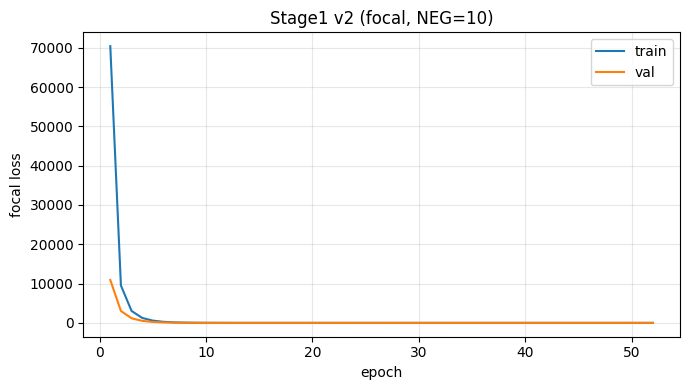

stage1_detector_v2.pth hazir.


In [10]:
try:
    os.makedirs(CKPT_DIR, exist_ok=True); safe_copy(STAGE1_LOCAL, STAGE1_DRIVE)
    print('Drive:', STAGE1_DRIVE, '(%.1f MB)'%(os.path.getsize(STAGE1_DRIVE)/1e6))
except Exception as e: print('Drive hata:', e, '- local var:', STAGE1_LOCAL)
ep=[h[0] for h in hist]
plt.figure(figsize=(7,4))
plt.plot(ep,[h[1] for h in hist],label='train'); plt.plot(ep,[h[2] for h in hist],label='val')
plt.xlabel('epoch'); plt.ylabel('focal loss'); plt.title('Stage1 v2 (focal, NEG=%g)'%NEG_PER_POS); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/stage1_v2_curve.png',dpi=120); plt.show()
print('stage1_detector_v2.pth hazir.')

## 11. Inference: find_candidates (sliding-window 3D)

In [11]:
ck=torch.load(STAGE1_LOCAL,map_location=device,weights_only=False)
model.load_state_dict(ck['model_state_dict']); model.eval()
@torch.no_grad()
def _heatmap_volume(volume, stride=(32,64,64), batch=4):
    Z0,Y0,X0=volume.shape; Zp,Yp,Xp=max(Z0,PZ),max(Y0,PY),max(X0,PX)
    if (Zp,Yp,Xp)!=(Z0,Y0,X0):
        v2=np.full((Zp,Yp,Xp),HU_CLIP[0],dtype=volume.dtype); v2[:Z0,:Y0,:X0]=volume; volume=v2
    Z,Y,X=volume.shape; acc=np.zeros((Z,Y,X),np.float32); cnt=np.zeros((Z,Y,X),np.float32)
    sz,sy,sx=stride
    zs=list(range(0,Z-PZ+1,sz))+([Z-PZ] if (Z-PZ)%sz else [])
    ys=list(range(0,Y-PY+1,sy))+([Y-PY] if (Y-PY)%sy else [])
    xs=list(range(0,X-PX+1,sx))+([X-PX] if (X-PX)%sx else [])
    coords=[(z,y,x) for z in zs for y in ys for x in xs]; buf=[]; pos=[]
    def flush():
        if not buf: return
        xb=torch.from_numpy(np.stack(buf)[:,None]).to(device)
        with autocast('cuda',dtype=torch.bfloat16): hm=torch.sigmoid(model(xb).float()).cpu().numpy()
        for k,(z,y,x) in enumerate(pos): acc[z:z+PZ,y:y+PY,x:x+PX]+=hm[k,0]; cnt[z:z+PZ,y:y+PY,x:x+PX]+=1
        buf.clear(); pos.clear()
    for (z,y,x) in coords:
        p=np.clip(volume[z:z+PZ,y:y+PY,x:x+PX].astype(np.float32),HU_CLIP[0],HU_CLIP[1])
        if p.mean()<HU_CLIP[0]+20: continue
        buf.append((p-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])); pos.append((z,y,x))
        if len(buf)>=batch: flush()
    flush(); cnt[cnt==0]=1; return (acc/cnt)[:Z0,:Y0,:X0]
def find_candidates_scored(volume, spacing, peak_thresh=0.05, cluster_mm=CLUSTER_MM):
    hm=_heatmap_volume(volume); mx=maximum_filter(hm,size=(5,9,9))
    peaks=np.argwhere((hm==mx)&(hm>=peak_thresh))
    if len(peaks)==0: return [],[]
    sc=hm[peaks[:,0],peaks[:,1],peaks[:,2]]; o=np.argsort(-sc); peaks=peaks[o]; sc=sc[o]
    sz,sy,sx=spacing; mm=peaks*np.array([sz,sy,sx]); taken=np.zeros(len(peaks),bool); out=[]; outs=[]
    for i in range(len(peaks)):
        if taken[i]: continue
        out.append(tuple(int(v) for v in peaks[i])); outs.append(float(sc[i]))
        taken|=(np.linalg.norm(mm-mm[i],axis=1)<cluster_mm)
    return out,outs
print('find_candidates hazir')

find_candidates hazir


## 12. FROC + CPM değerlendirme

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

  Tarama: 27 | Toplam nodul (GT): 48
  CPM: 0.629
      @0.125 FP/scan -> sens 0.383
      @ 0.25 FP/scan -> sens 0.409
      @  0.5 FP/scan -> sens 0.444
      @    1 FP/scan -> sens 0.590
      @    2 FP/scan -> sens 0.754
      @    4 FP/scan -> sens 0.898
      @    8 FP/scan -> sens 0.927
  Operating point (thr=0.3): ort. mesafe 1.85 mm (medyan 1.45)
  Boyuta gore sensitivity (operating point):
      kucuk(<6mm) : 0/0 = 0.00
      orta(6-10)  : 10/20 = 0.50
      buyuk(>10)  : 11/28 = 0.39


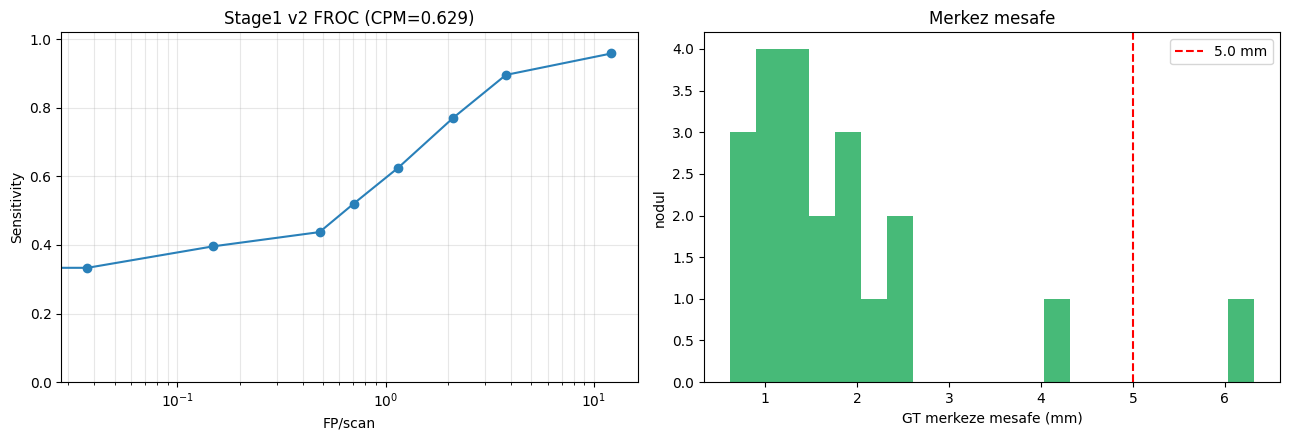


v2 degerlendirme tamam. NB14 (CPM 0.228, ~110 FP/scan) ile karsilastir.


In [12]:
def full_evaluation(scan_ids, max_scans=40):
    recs=[]; total_gt=0; n_scans=0; op_dists=[]
    size_tot={'kucuk(<6mm)':0,'orta(6-10)':0,'buyuk(>10)':0}; size_hit=dict.fromkeys(size_tot,0); gid=0
    sel=scan_ids if max_scans is None else scan_ids[:max_scans]
    for sid in tqdm(sel,desc='Eval'):
        if not os.path.exists(sid_to_npz(sid)): continue
        f=np.load(sid_to_npz(sid),allow_pickle=True); vol=f['scan']; spacing=tuple(f['spacing'])
        cands,scores=find_candidates_scored(vol,spacing)
        gts=val_index.get(sid,{}).get('nodules',[]); n_scans+=1; total_gt+=len(gts)
        cmm=np.array([[c[0]*spacing[0],c[1]*spacing[1],c[2]*spacing[2]] for c in cands]) if cands else np.zeros((0,3))
        gmm=[np.array([g[0]*spacing[0],g[1]*spacing[1],g[2]*spacing[2]]) for g in gts]
        radii=[max(MATCH_MM,g[3]/2) for g in gts]; gloc={}
        for gi,g in enumerate(gts):
            gloc[gi]=gid; gid+=1
            d=g[3]; key='kucuk(<6mm)' if d<6 else ('orta(6-10)' if d<=10 else 'buyuk(>10)'); size_tot[key]+=1
        for ci in range(len(cands)):
            best=-1; bestd=1e9
            for gi in range(len(gts)):
                dd=np.linalg.norm(cmm[ci]-gmm[gi])
                if dd<=radii[gi] and dd<bestd: bestd=dd; best=gloc[gi]
            recs.append((scores[ci], best))
        kept=[(c,s) for c,s in zip(cands,scores) if s>=PEAK_THRESH]
        kmm=np.array([[c[0]*spacing[0],c[1]*spacing[1],c[2]*spacing[2]] for c,_ in kept]) if kept else np.zeros((0,3))
        for gi,g in enumerate(gts):
            d=g[3]; key='kucuk(<6mm)' if d<6 else ('orta(6-10)' if d<=10 else 'buyuk(>10)')
            if len(kmm)>0:
                dd=np.linalg.norm(kmm-gmm[gi],axis=1); j=int(np.argmin(dd))
                if dd[j]<=radii[gi]: op_dists.append(float(dd[j])); size_hit[key]+=1
        del f,vol; gc.collect()
    if len(recs)==0: print('Hic aday yok!'); return 0.0
    recs=np.array(recs,dtype=float)
    ths=np.linspace(0.05,0.95,19); sens=[]; fpps=[]
    for th in ths:
        m=recs[:,0]>=th; hit=set(int(g) for g in recs[m,1] if g>=0); fp=int(np.sum(recs[m,1]<0))
        sens.append(len(hit)/max(total_gt,1)); fpps.append(fp/max(n_scans,1))
    sens=np.array(sens); fpps=np.array(fpps)
    pts=[0.125,0.25,0.5,1,2,4,8]; order=np.argsort(fpps)
    cpm_each=[float(np.interp(p,fpps[order],sens[order])) for p in pts]; cpm=float(np.mean(cpm_each))
    print('='*56)
    print(f'  Tarama: {n_scans} | Toplam nodul (GT): {total_gt}')
    print(f'  CPM: {cpm:.3f}')
    for p,s in zip(pts,cpm_each): print(f'      @{p:>5} FP/scan -> sens {s:.3f}')
    if op_dists: print(f'  Operating point (thr={PEAK_THRESH}): ort. mesafe {np.mean(op_dists):.2f} mm (medyan {np.median(op_dists):.2f})')
    print('  Boyuta gore sensitivity (operating point):')
    for k in size_tot: print(f'      {k:12s}: {size_hit[k]}/{size_tot[k]} = {size_hit[k]/max(size_tot[k],1):.2f}')
    print('='*56)
    fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    ax[0].plot(fpps,sens,'o-',c='#2980b9'); ax[0].set_xscale('log'); ax[0].set_xlabel('FP/scan'); ax[0].set_ylabel('Sensitivity'); ax[0].set_ylim(0,1.02)
    ax[0].set_title(f'Stage1 v2 FROC (CPM={cpm:.3f})'); ax[0].grid(alpha=0.3,which='both')
    if op_dists:
        ax[1].hist(op_dists,bins=20,color='#27ae60',alpha=0.85); ax[1].axvline(MATCH_MM,ls='--',c='r',label=f'{MATCH_MM} mm')
        ax[1].set_xlabel('GT merkeze mesafe (mm)'); ax[1].set_ylabel('nodul'); ax[1].set_title('Merkez mesafe'); ax[1].legend()
    plt.tight_layout(); plt.savefig('/content/stage1_v2_froc.png',dpi=120); plt.show()
    return cpm
cpm=full_evaluation(meta['scans']['val'], max_scans=40)
print('\nv2 degerlendirme tamam. NB14 (CPM 0.228, ~110 FP/scan) ile karsilastir.')

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

  Tarama: 27 | GT nodul: 48 | CPM(8FP): 0.625
      @0.125 FP/scan -> sens 0.370
      @ 0.25 FP/scan -> sens 0.404
      @  0.5 FP/scan -> sens 0.469
      @    1 FP/scan -> sens 0.612
      @    2 FP/scan -> sens 0.717
      @    4 FP/scan -> sens 0.896
      @    8 FP/scan -> sens 0.904
      @   16 FP/scan -> sens 0.956
      @   32 FP/scan -> sens 0.959
  Max sensitivity (tavan): 0.979 @ 380 FP/scan


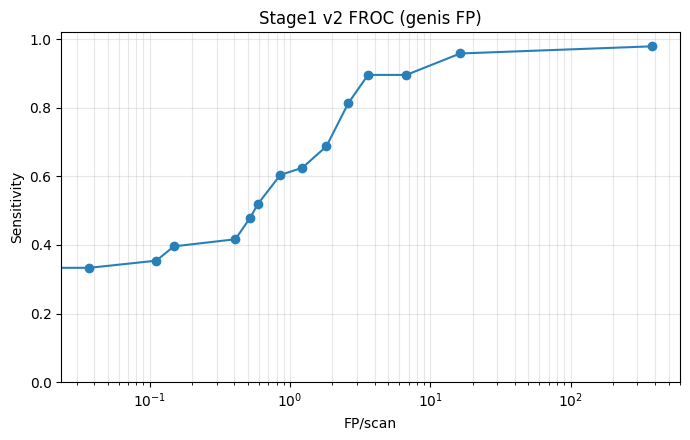

In [13]:
def find_candidates_scored(volume, spacing, peak_thresh=0.01, cluster_mm=CLUSTER_MM):  # 0.05->0.01
    hm=_heatmap_volume(volume); mx=maximum_filter(hm,size=(5,9,9))
    peaks=np.argwhere((hm==mx)&(hm>=peak_thresh))
    if len(peaks)==0: return [],[]
    sc=hm[peaks[:,0],peaks[:,1],peaks[:,2]]; o=np.argsort(-sc); peaks=peaks[o]; sc=sc[o]
    sz,sy,sx=spacing; mm=peaks*np.array([sz,sy,sx]); taken=np.zeros(len(peaks),bool); out=[]; outs=[]
    for i in range(len(peaks)):
        if taken[i]: continue
        out.append(tuple(int(v) for v in peaks[i])); outs.append(float(sc[i]))
        taken|=(np.linalg.norm(mm-mm[i],axis=1)<cluster_mm)
    return out,outs

def full_evaluation(scan_ids, max_scans=40):
    recs=[]; total_gt=0; n_scans=0; op_dists=[]
    sel=scan_ids if max_scans is None else scan_ids[:max_scans]
    for sid in tqdm(sel,desc='Eval'):
        if not os.path.exists(sid_to_npz(sid)): continue
        f=np.load(sid_to_npz(sid),allow_pickle=True); vol=f['scan']; spacing=tuple(f['spacing'])
        cands,scores=find_candidates_scored(vol,spacing)
        gts=val_index.get(sid,{}).get('nodules',[]); n_scans+=1; total_gt+=len(gts)
        cmm=np.array([[c[0]*spacing[0],c[1]*spacing[1],c[2]*spacing[2]] for c in cands]) if cands else np.zeros((0,3))
        gmm=[np.array([g[0]*spacing[0],g[1]*spacing[1],g[2]*spacing[2]]) for g in gts]
        radii=[max(MATCH_MM,g[3]/2) for g in gts]
        for ci in range(len(cands)):
            best=-1; bestd=1e9
            for gi in range(len(gts)):
                dd=np.linalg.norm(cmm[ci]-gmm[gi])
                if dd<=radii[gi] and dd<bestd: bestd=dd; best=gi+n_scans*1000
            recs.append((scores[ci], best))
        del f,vol; gc.collect()
    recs=np.array(recs,dtype=float)
    ths=np.linspace(0.01,0.9,30); sens=[]; fpps=[]
    for th in ths:
        m=recs[:,0]>=th; hit=set(int(g) for g in recs[m,1] if g>=0); fp=int(np.sum(recs[m,1]<0))
        sens.append(len(hit)/max(total_gt,1)); fpps.append(fp/max(n_scans,1))
    sens=np.array(sens); fpps=np.array(fpps)
    pts=[0.125,0.25,0.5,1,2,4,8,16,32]; order=np.argsort(fpps)
    cpm_each=[float(np.interp(p,fpps[order],sens[order])) for p in pts]
    cpm=float(np.mean(cpm_each[:7]))  # standart CPM (8 FP'ye kadar)
    print('='*56)
    print(f'  Tarama: {n_scans} | GT nodul: {total_gt} | CPM(8FP): {cpm:.3f}')
    for p,s in zip(pts,cpm_each): print(f'      @{p:>5} FP/scan -> sens {s:.3f}')
    print(f'  Max sensitivity (tavan): {sens.max():.3f} @ {fpps[sens.argmax()]:.0f} FP/scan')
    print('='*56)
    plt.figure(figsize=(7,4.5))
    plt.plot(fpps,sens,'o-',c='#2980b9'); plt.xscale('log'); plt.ylim(0,1.02)
    plt.xlabel('FP/scan'); plt.ylabel('Sensitivity'); plt.title(f'Stage1 v2 FROC (genis FP)'); plt.grid(alpha=0.3,which='both')
    plt.tight_layout(); plt.savefig('/content/stage1_v2_froc_wide.png',dpi=120); plt.show()
    return cpm
cpm=full_evaluation(meta['scans']['val'], max_scans=40)